# Step 5 — Evaluate on Real Test Set

Load the best checkpoint, run inference on all clean test-set galaxies, and produce one evaluation figure per morphological parameter.

Each figure has the same layout as the CNN-redshift evaluation:
- **Top-left:** predicted vs true scatter with KDE contours + global stats
- **Bottom-left:** mean bias (pred − true) per bin ± σ_NMAD
- **Top-right:** per-bin mean |residual| curve
- **Bottom-right:** DDPM − GT difference bar chart *(filled in Step 6)*

## 5.1 Imports, paths & helpers

In [5]:
import os, sys, json
import numpy as np
import h5py
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from scipy.stats import gaussian_kde

HERE = os.path.dirname(os.path.abspath("step5_evaluate_testset.ipynb"))
sys.path.insert(0, HERE)
from model import MorphCNN


# using GalaxyML test
DATA_DIR  = "/Users/wen/Desktop/project/archive"
HDF5_TEST = os.path.join(DATA_DIR, "5x64x64_testing_with_morphology.hdf5")
CKPT_BEST = os.path.join(HERE, "checkpoints", "best.pt")

TARGET_COLS   = ["g_ellipticity", "g_major_axis", "g_sersic_index", "g_isophotal_area"]
PARAM_LABELS  = ["Ellipticity", "Major Axis (arcsec)", "Sérsic Index n", "Isophotal Area (px²)"]
PARAM_SHORT   = ["ellipticity", "major_axis", "sersic_index", "isophotal_area"]
DEVICE        = "mps" if torch.backends.mps.is_available() else "cpu"

with open(os.path.join(HERE, "normaliser.json")) as fp:
    NORM = json.load(fp)
with open(os.path.join(HERE, "image_stats.json")) as fp:
    img_stats = json.load(fp)

IMG_MEAN = torch.tensor(img_stats["mean"], dtype=torch.float32).view(5,1,1)
IMG_STD  = torch.tensor(img_stats["std"],  dtype=torch.float32).view(5,1,1)

def denormalise(arr):
    """(N,4) normalised numpy -> (N,4) original scale."""
    out = []
    for i, col in enumerate(TARGET_COLS):
        v = arr[:, i].copy()
        v = v * NORM[col]["std"] + NORM[col]["mean"]
        t = NORM[col]["transform"]
        if t == "log1p": v = np.expm1(v)
        elif t == "log":  v = np.exp(v)
        out.append(v)
    return np.stack(out, axis=1)

def sigma_nmad(residuals):
    return 1.4826 * np.median(np.abs(residuals - np.median(residuals)))

## 5.2 Load model & run inference on test set

In [ ]:
model = MorphCNN(n_outputs=4).to(DEVICE)
ckpt  = torch.load(CKPT_BEST, map_location=DEVICE, weights_only=True)
model.load_state_dict(ckpt["model"])
model.eval()
print(f"Loaded best checkpoint  (val_loss = {ckpt['val_loss']:.5f},  epoch {ckpt['epoch']})")

test_idx = np.load(os.path.join(HERE, "indices_test.npy"))
n_test   = len(test_idx)
print(f"Test set: {n_test:,} clean samples")

# ── load test data in chunks (no shuffle needed) ───────────────────────────
BATCH = 512
all_preds = []
all_true  = []

with h5py.File(HDF5_TEST, "r") as f:
    for s in range(0, n_test, BATCH):
        ci   = test_idx[s : s + BATCH]
        imgs = torch.from_numpy(f["image"][ci].astype(np.float32))
        imgs = (torch.arcsinh(imgs) - IMG_MEAN) / IMG_STD

        with torch.no_grad():
            pred_norm = model(imgs.to(DEVICE)).cpu().numpy()  # inference: predict and normalize

        true_raw = np.stack([f[col][ci] for col in TARGET_COLS], axis=1).astype(np.float32)  # true lable is cateloge g-band
        all_preds.append(pred_norm)
        all_true.append(true_raw)

        if (s // BATCH) % 10 == 0:
            print(f"  {s + len(ci):>6,} / {n_test:,}", end="\r")

preds_norm = np.concatenate(all_preds)          # (N, 4) normalised
true_raw   = np.concatenate(all_true)           # (N, 4) original scale

# de-normalise predictions back to physical units
preds_raw  = denormalise(preds_norm)            # (N, 4) original scale

print(f"\nInference done.  preds shape: {preds_raw.shape}")

# save for Step 6
np.save(os.path.join(HERE, "test_preds.npy"), preds_raw)
np.save(os.path.join(HERE, "test_true.npy"),  true_raw)
print("Saved test_preds.npy and test_true.npy")

Loaded best checkpoint  (val_loss = 0.03508,  epoch 22)
Test set: 40,891 clean samples
  36,352 / 40,891
Inference done.  preds shape: (40891, 4)
Saved test_preds.npy and test_true.npy


## 5.3 Global metrics table

In [7]:
from sklearn.metrics import r2_score

print(f"{'Parameter':<22} {'Bias':>10} {'σ_NMAD':>10} {'R²':>8} {'N_out (>20%)':>14}")
print("-" * 68)
metrics = {}
for i, (col, label) in enumerate(zip(TARGET_COLS, PARAM_LABELS)):
    p = preds_raw[:, i]
    t = true_raw[:, i]
    res      = p - t
    bias     = np.mean(res)
    nmad     = sigma_nmad(res / (1 + t) if t.min() > -1 else res)
    r2       = r2_score(t, p)
    frac_res = np.abs(res) / (np.abs(t) + 1e-8)
    n_out    = np.sum(frac_res > 0.20)
    pct_out  = 100 * n_out / len(t)
    metrics[col] = dict(bias=bias, nmad=nmad, r2=r2, n_out=n_out, pct_out=pct_out)
    print(f"  {label:<20} {bias:>10.4f} {nmad:>10.4f} {r2:>8.4f} {n_out:>8,} ({pct_out:.1f}%)")

Parameter                    Bias     σ_NMAD       R²   N_out (>20%)
--------------------------------------------------------------------
  Ellipticity              0.0025     0.0276   0.8813   15,849 (38.8%)
  Major Axis (arcsec)     -0.0448     0.0438   0.9696    2,098 (5.1%)
  Sérsic Index n          -0.0383     0.0417   0.8194    4,801 (11.7%)
  Isophotal Area (px²)   -32.0666     0.1008   0.9566    5,176 (12.7%)


## 5.4 Evaluation figures — one per parameter

Same 4-panel layout as the CNN-redshift figure:
- **Top-left:** scatter predicted vs true + KDE contours (8,000-point subsample)
- **Bottom-left:** mean bias per bin ± σ_NMAD
- **Top-right:** mean |residual| per bin (used in Step 6 comparison)
- **Bottom-right:** placeholder for DDPM − GT bar chart (Step 6)

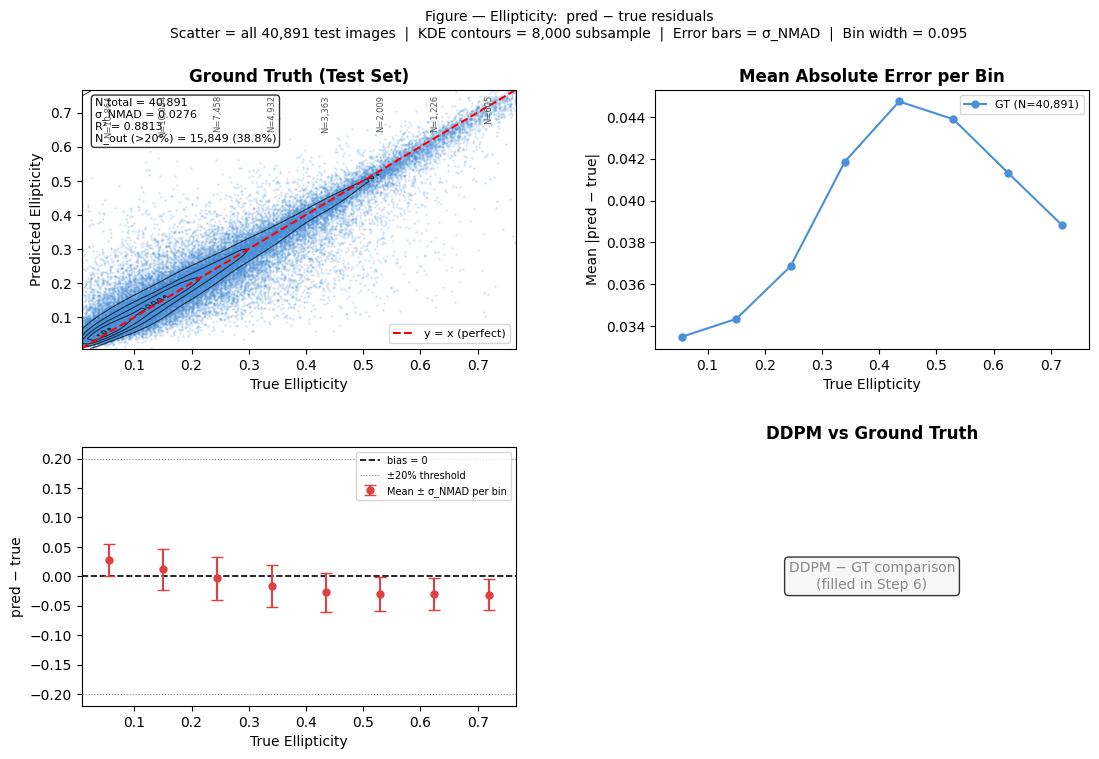

Saved eval_testset_ellipticity.png



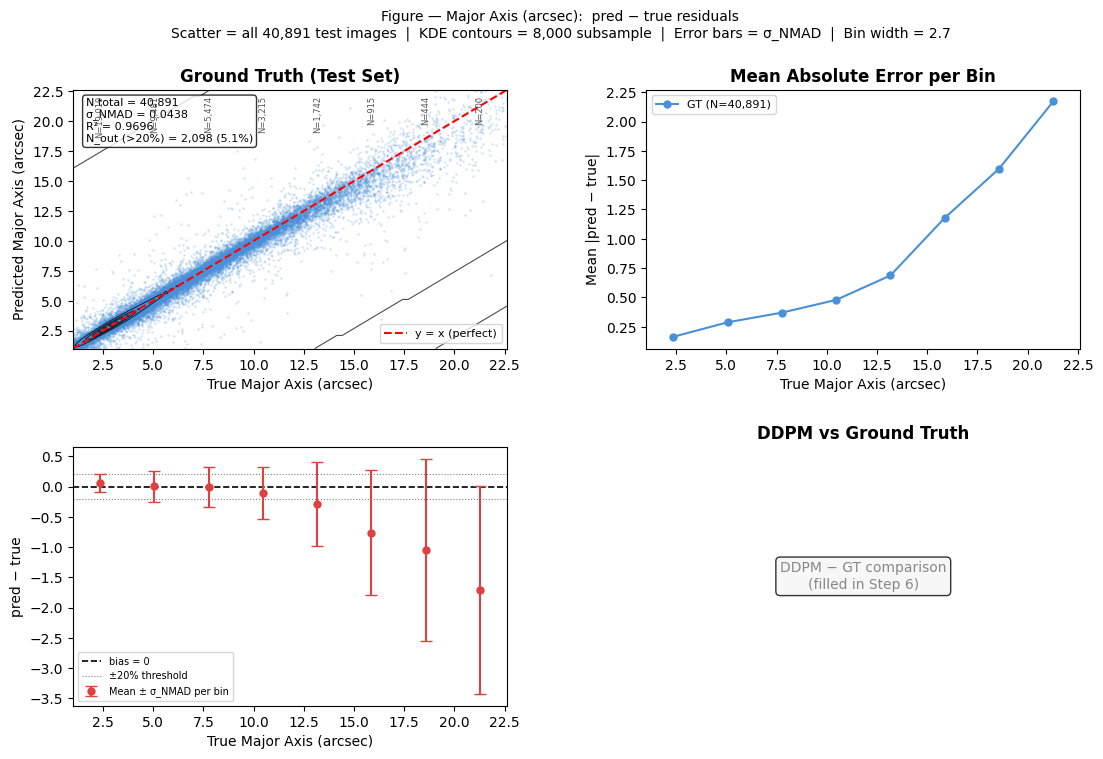

Saved eval_testset_major_axis.png



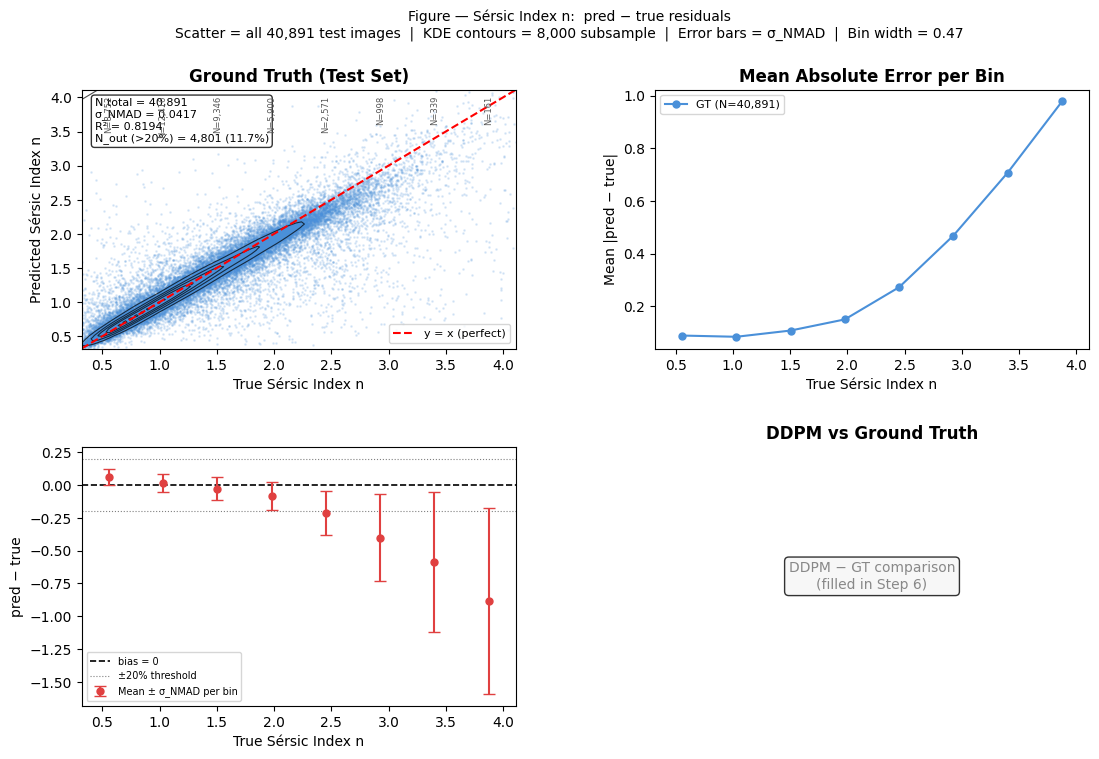

Saved eval_testset_sersic_index.png



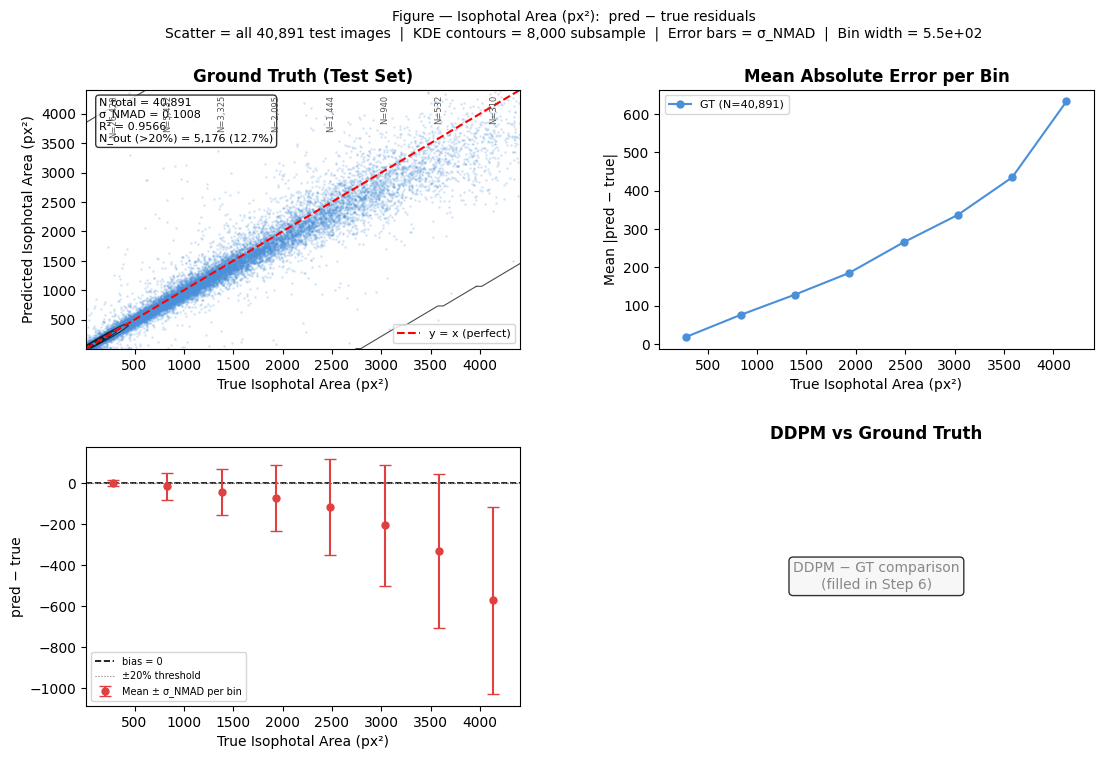

Saved eval_testset_isophotal_area.png



In [8]:
def bin_stats(true, residuals, bins):
    """Return bin centres, mean residual, σ_NMAD, counts per bin."""
    centres, means, nmads, counts = [], [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (true >= lo) & (true < hi)
        if mask.sum() < 5:
            continue
        r = residuals[mask]
        centres.append(0.5 * (lo + hi))
        means.append(np.mean(r))
        nmads.append(sigma_nmad(r))
        counts.append(mask.sum())
    return np.array(centres), np.array(means), np.array(nmads), np.array(counts)


rng = np.random.default_rng(42)
KDE_N = 8000   # subsample for KDE (same as redshift figure)

for i, (col, label, short) in enumerate(zip(TARGET_COLS, PARAM_LABELS, PARAM_SHORT)):
    p = preds_raw[:, i]
    t = true_raw[:, i]
    res = p - t
    m   = metrics[col]

    # axis limits — clip to 1st–99th percentile of true values
    vlo, vhi = np.percentile(t, 0.5), np.percentile(t, 99.5)

    # bins for residual plots (8 equal-width bins)
    bins = np.linspace(vlo, vhi, 9)
    bx, bmean, bnmad, bcounts = bin_stats(t, res, bins)
    bx2, bmean_abs, _, _      = bin_stats(t, np.abs(res), bins)

    # KDE on subsample
    idx_kde = rng.choice(len(t), size=min(KDE_N, len(t)), replace=False)
    xy      = np.vstack([t[idx_kde], p[idx_kde]])
    kde     = gaussian_kde(xy, bw_method=0.15)
    xg, yg  = np.mgrid[vlo:vhi:80j, vlo:vhi:80j]
    zg      = kde(np.vstack([xg.ravel(), yg.ravel()])).reshape(80, 80)

    # ── figure ──────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(13, 8))
    fig.suptitle(
        f"Figure — {label}:  pred − true residuals\n"
        f"Scatter = all {len(t):,} test images  |  KDE contours = {KDE_N:,} subsample"
        f"  |  Error bars = σ_NMAD  |  Bin width = {(vhi-vlo)/8:.2g}",
        fontsize=10
    )

    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)
    ax_scatter  = fig.add_subplot(gs[0, 0])
    ax_residual = fig.add_subplot(gs[1, 0])
    ax_abs_err  = fig.add_subplot(gs[0, 1])
    ax_bar      = fig.add_subplot(gs[1, 1])

    # ── scatter + KDE ───────────────────────────────────────────────────────
    ax_scatter.scatter(t, p, s=1, alpha=0.15, color="#4a90d9", rasterized=True)
    ax_scatter.contour(xg, yg, zg, levels=5, colors="k", linewidths=0.8, alpha=0.7)
    ax_scatter.plot([vlo, vhi], [vlo, vhi], "r--", lw=1.5, label="y = x (perfect)")
    ax_scatter.set_xlim(vlo, vhi); ax_scatter.set_ylim(vlo, vhi)
    ax_scatter.set_xlabel(f"True {label}"); ax_scatter.set_ylabel(f"Predicted {label}")
    ax_scatter.set_title("Ground Truth (Test Set)", fontweight="bold")
    stats_text = (f"N total = {len(t):,}\n"
                  f"σ_NMAD = {m['nmad']:.4f}\n"
                  f"R² = {m['r2']:.4f}\n"
                  f"N_out (>20%) = {m['n_out']:,} ({m['pct_out']:.1f}%)")
    ax_scatter.text(0.03, 0.97, stats_text, transform=ax_scatter.transAxes,
                    fontsize=8, va="top", bbox=dict(fc="white", alpha=0.8, boxstyle="round"))
    ax_scatter.legend(fontsize=8, loc="lower right")

    # ── per-bin counts ───────────────────────────────────────────────────────
    for j, (xc, cnt) in enumerate(zip(bx, bcounts)):
        ax_scatter.text(xc, vhi * 0.98, f"N={cnt:,}", ha="center", va="top",
                        fontsize=6, color="#555", rotation=90)

    # ── residual per bin ────────────────────────────────────────────────────
    ax_residual.axhline(0, color="k", lw=1.2, ls="--", label="bias = 0")
    ax_residual.axhline( 0.2, color="gray", lw=0.8, ls=":")
    ax_residual.axhline(-0.2, color="gray", lw=0.8, ls=":", label="±20% threshold")
    ax_residual.errorbar(bx, bmean, yerr=bnmad, fmt="o", color="#e04040",
                         capsize=4, ms=5, label="Mean ± σ_NMAD per bin")
    ax_residual.set_xlabel(f"True {label}")
    ax_residual.set_ylabel("pred − true")
    ax_residual.legend(fontsize=7)
    ax_residual.set_xlim(vlo, vhi)

    # ── mean |residual| per bin (top-right) ─────────────────────────────────
    ax_abs_err.plot(bx2, bmean_abs, "o-", color="#4a90d9", ms=5, lw=1.5,
                    label=f"GT (N={len(t):,})")
    ax_abs_err.set_xlabel(f"True {label}")
    ax_abs_err.set_ylabel("Mean |pred − true|")
    ax_abs_err.set_title("Mean Absolute Error per Bin", fontweight="bold")
    ax_abs_err.legend(fontsize=8)
    ax_abs_err.set_xlim(vlo, vhi)

    # ── DDPM bar chart placeholder (bottom-right) ────────────────────────────
    ax_bar.text(0.5, 0.5, "DDPM − GT comparison\n(filled in Step 6)",
                ha="center", va="center", transform=ax_bar.transAxes,
                fontsize=10, color="#888",
                bbox=dict(fc="#f5f5f5", boxstyle="round", alpha=0.8))
    ax_bar.set_title("DDPM vs Ground Truth", fontweight="bold")
    ax_bar.axis("off")

    plt.savefig(os.path.join(HERE, f"figures/eval_testset_{short}.png"),
                dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Saved eval_testset_{short}.png\n")